# Notebook 4: Sensor Redundancy & Prediction

Predicts each raw sensor from all others to quantify redundancy. A high R² means the sensor's information is captured by others — it is redundant. Includes threshold sweep to find a minimal sensor set.


In [1]:
# Installing kagglehub(for dataset) and shap
!pip install -q kagglehub shap
# install torch only if missing
try:
    import torch
except ImportError:
    !pip install -q torch

In [2]:
# Importing libraries and packages

import kagglehub, os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix,
                             accuracy_score, f1_score)

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize':(12,5), 'font.size':12})
np.random.seed(42)

# Importing PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Running on: {DEVICE}')

🖥️  Running on: cpu


## Loading Dataset

In [4]:
# Fetching Dataset

path = kagglehub.dataset_download('fedesoriano/cern-electron-collision-data')
df = pd.read_csv(os.path.join(path, 'dielectron.csv'))
df.columns = df.columns.str.strip()

100%|██████████| 6.25M/6.25M [00:00<00:00, 8.55MB/s]

Extracting files...


In [5]:
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 19)


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


## Preprocessing

In [6]:
# Dropping Null and Duplicates
df = df.dropna(subset=['M']).drop_duplicates().reset_index(drop=True)

# Dropping Run and Event (They have no role in training the model)
df = df.drop(columns=['Run', 'Event'], errors='ignore')

## Feature Engineering (Creating 9 new features)

In [7]:
# Feature Engineering
# Physics-motivated features
df['delta_eta'] = df['eta1'] - df['eta2']
df['delta_phi'] = df['phi1'] - df['phi2']
df['delta_R']   = np.sqrt(df['delta_eta']**2 + df['delta_phi']**2)
df['pt_total']  = df['pt1'] + df['pt2']
df['pt_asym']   = (df['pt1'] - df['pt2']) / (df['pt1'] + df['pt2'] + 1e-10)
df['E_total']   = df['E1'] + df['E2']
df['E_ratio']   = df['E1'] / (df['E2'] + 1e-10)
df['Q_sum']     = df['Q1'] + df['Q2']
df['cos_theta_star'] = np.tanh(df['delta_eta'] / 2)

print(f'After cleaning: {df.shape}')
print(f'Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star')

After cleaning: (99892, 26)
Features created: delta_eta, delta_phi, delta_R, pt_total, pt_asym, E_total, E_ratio, Q_sum, cos_theta_star


For classification evaluation, we bin M into 4 physics-motivated classes:
- **J/ψ region**: 2 ≤ M < 6 GeV
- **Υ region**: 6 ≤ M < 15 GeV  
- **Continuum**: 15 ≤ M < 70 GeV
- **Z boson**: M ≥ 70 GeV

In [8]:
# Defining M bins for classification evaluation
def mass_to_class(m):
    # Binnig invariant mass into 4 physics-motivated classes.
    if m < 6:
        return 'J/psi_region'
    elif m < 15:
        return 'Upsilon_region'
    elif m < 70:
        return 'Continuum'
    else:
        return 'Z_boson'

df['label'] = df['M'].apply(mass_to_class)
print('\nClass distribution:')
print(df['label'].value_counts().sort_index())

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(f'\nClasses: {list(le.classes_)}')


Class distribution:
label
Continuum         55993
J/psi_region       9847
Upsilon_region    22910
Z_boson           11142
Name: count, dtype: int64

Classes: ['Continuum', 'J/psi_region', 'Upsilon_region', 'Z_boson']


## Separating target value and feature columns

In [9]:
# Define features and target
# All sensor/physical property columns (everything except M and derived labels)
feature_cols = [c for c in df.columns if c not in ['M', 'label', 'label_enc']]
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].values
y_reg = df['M'].values          # Regression target: continuous M
y_cls = df['label_enc'].values   # Classification target: binned M

# Train/Test Split
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42
)

# ── Standardise ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train_s.shape}, Test: {X_test_s.shape}')

Feature columns (25): ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'delta_eta', 'delta_phi', 'delta_R', 'pt_total', 'pt_asym', 'E_total', 'E_ratio', 'Q_sum', 'cos_theta_star']

Train: (79913, 25), Test: (19979, 25)


In [10]:
# Baseline full linear regression (needed for threshold comparison)
lr_full = LinearRegression()
lr_full.fit(X_train_s, y_train_reg)
y_pred_lr_full = lr_full.predict(X_test_s)
r2_lr_full   = r2_score(y_test_reg, y_pred_lr_full)
rmse_lr_full = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_full))
print(f'Baseline LR → R²={r2_lr_full:.4f}, RMSE={rmse_lr_full:.4f}')

Baseline LR → R²=0.6767, RMSE=14.3543


## Sensor Redundancy Analysis

**Approach**: Predict each sensor's value using data from all other sensors (via linear regression).  
If a sensor can be accurately predicted from others, it is **redundant** — meaning its information is already captured by the other sensors.

A high R² indicates the sensor is predictable (hence redundant); low R² means the sensor provides unique information.

In [11]:
# Predicting each sensor's value from all others
raw_sensor_cols = ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1',
                   'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2']

redundancy_results = {}
for target_col in raw_sensor_cols:
    other_cols = [c for c in raw_sensor_cols if c != target_col]

    col_idx_target = feature_cols.index(target_col)
    col_idx_others = [feature_cols.index(c) for c in other_cols]

    X_tr = X_train_s[:, col_idx_others]
    X_te = X_test_s[:, col_idx_others]
    y_tr = X_train_s[:, col_idx_target]
    y_te = X_test_s[:, col_idx_target]

    lr_temp = LinearRegression()
    lr_temp.fit(X_tr, y_tr)
    y_pred = lr_temp.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    redundancy_results[target_col] = {'r2': r2, 'rmse': rmse}

# Sorting by R² in descending order (most redundant first)
sorted_redundancy = sorted(redundancy_results.items(), key=lambda x: -x[1]['r2'])

print('═══ Sensor Redundancy Analysis ═══')
print('(Predicting each sensor from all others using Linear Regression)')
print(f'\n{"Sensor":>10s} | {"R²":>8s} | {"RMSE":>8s} | {"Redundancy":>12s}')
print('-' * 50)
for name, res in sorted_redundancy:
    label = 'HIGH' if res['r2'] > 0.9 else ('MEDIUM' if res['r2'] > 0.5 else 'LOW')
    print(f'{name:>10s} | {res["r2"]:8.4f} | {res["rmse"]:8.4f} | {label:>12s}')

═══ Sensor Redundancy Analysis ═══
(Predicting each sensor from all others using Linear Regression)

    Sensor |       R² |     RMSE |   Redundancy
--------------------------------------------------
        E2 |   0.6108 |   0.6197 |       MEDIUM
       pt2 |   0.6098 |   0.6119 |       MEDIUM
      eta2 |   0.5963 |   0.6363 |       MEDIUM
       pz2 |   0.5925 |   0.6380 |       MEDIUM
      eta1 |   0.5915 |   0.6406 |       MEDIUM
       pz1 |   0.5865 |   0.6549 |       MEDIUM
       pt1 |   0.5501 |   0.6798 |       MEDIUM
        E1 |   0.5386 |   0.6967 |       MEDIUM
       py1 |   0.3967 |   0.7787 |          LOW
       py2 |   0.3807 |   0.7845 |          LOW
      phi1 |   0.3539 |   0.8032 |          LOW
      phi2 |   0.3397 |   0.8070 |          LOW
       px2 |   0.1092 |   0.9295 |          LOW
       px1 |   0.1089 |   0.9536 |          LOW
        Q2 |   0.0183 |   0.9908 |          LOW
        Q1 |   0.0173 |   0.9911 |          LOW


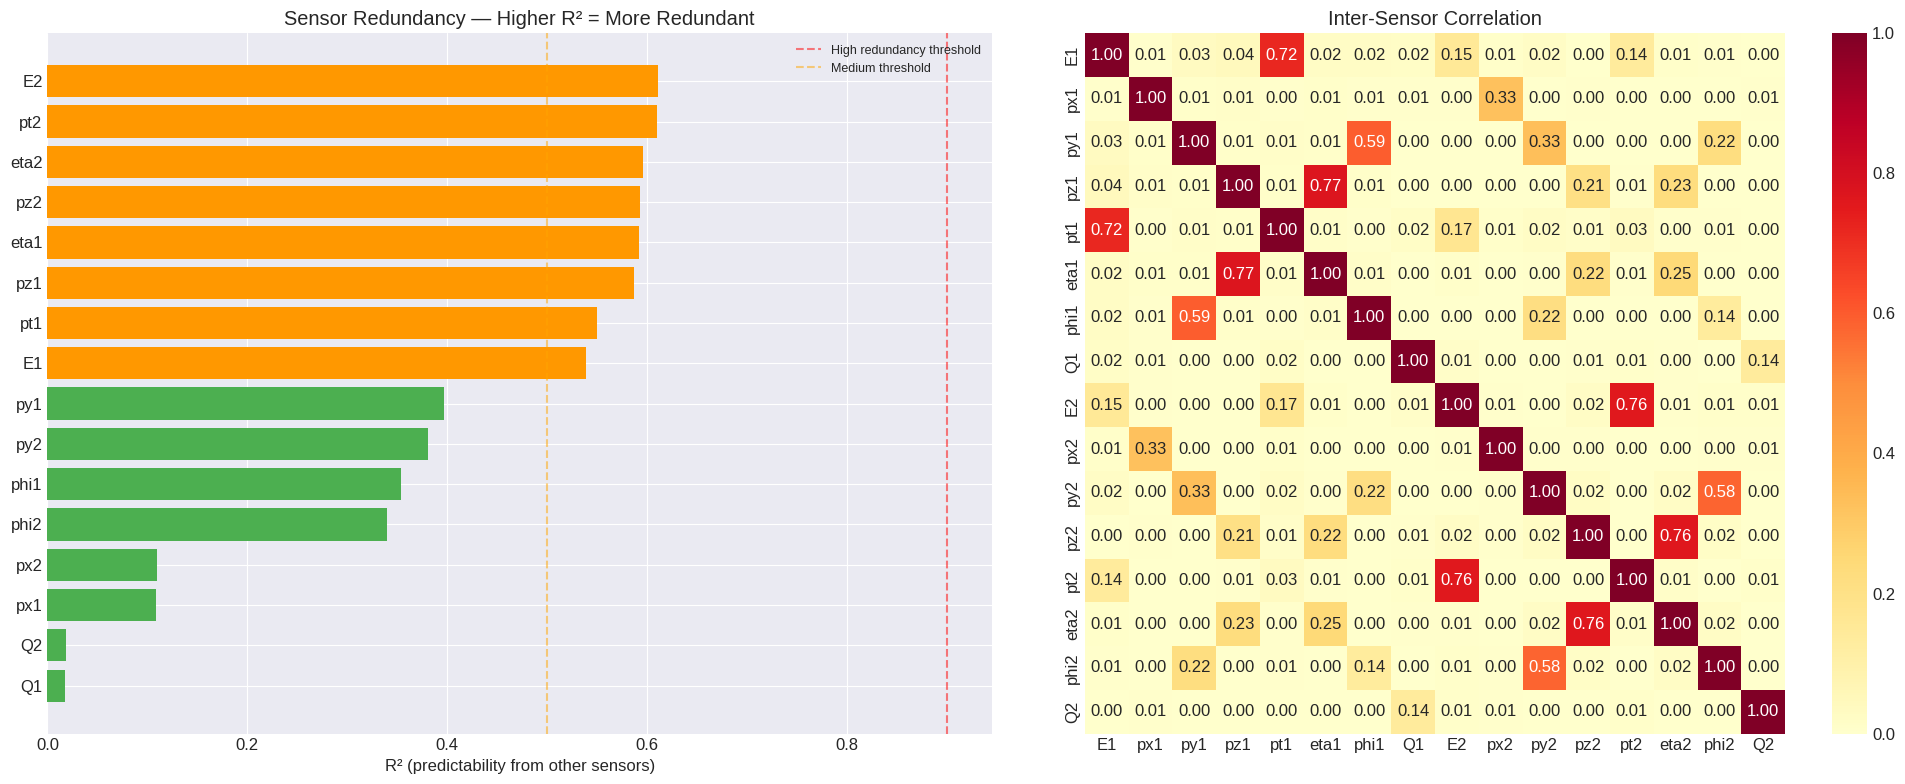


 Highly redundant sensors (R² > 0.9): []
   → These sensors can be predicted well from other sensors and may be removable.

 Unique/non-redundant sensors (R² < 0.5): ['py1', 'py2', 'phi1', 'phi2', 'px2', 'px1', 'Q2', 'Q1']
   → These sensors provide unique information not captured by others.


In [12]:
# Redundancy Visualisation
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sensor_names = [s[0] for s in sorted_redundancy]
r2_vals = [s[1]['r2'] for s in sorted_redundancy]

colors_rd = ['#F44336' if v > 0.9 else '#FF9800' if v > 0.5 else '#4CAF50' for v in r2_vals]

bars = axes[0].barh(sensor_names, r2_vals, color=colors_rd)
axes[0].set_xlabel('R² (predictability from other sensors)')
axes[0].set_title('Sensor Redundancy — Higher R² = More Redundant')
axes[0].axvline(0.9, color='red', ls='--', alpha=0.5, label='High redundancy threshold')
axes[0].axvline(0.5, color='orange', ls='--', alpha=0.5, label='Medium threshold')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Heatmap of inter-sensor correlation
sensor_corr = df[raw_sensor_cols].corr().abs()
sns.heatmap(sensor_corr, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], square=True, vmin=0, vmax=1)
axes[1].set_title('Inter-Sensor Correlation')

plt.tight_layout(); plt.show()

# Summary
high_redundancy = [s[0] for s in sorted_redundancy if s[1]['r2'] > 0.9]
low_redundancy = [s[0] for s in sorted_redundancy if s[1]['r2'] < 0.5]
print(f'\n Highly redundant sensors (R² > 0.9): {high_redundancy}')
print(f'   → These sensors can be predicted well from other sensors and may be removable.')
print(f'\n Unique/non-redundant sensors (R² < 0.5): {low_redundancy}')
print(f'   → These sensors provide unique information not captured by others.')

### Lower Redundancy Threshold Exploration

Even sensors with R² ~0.5–0.9 have partial redundancy.
We test whether removing sensors above progressively lower thresholds
still preserves M prediction quality.

═══ Redundancy Threshold Exploration ═══
  Baseline (all features): R²=0.6767, RMSE=14.3543

   Threshold | Removed | Remaining |       R² |     RMSE |     R² Δ
  -----------------------------------------------------------------
         0.9 |       0 |        25 |   0.6767 |  14.3543 |  +0.0000
         0.8 |       0 |        25 |   0.6767 |  14.3543 |  +0.0000
         0.7 |       0 |        25 |   0.6767 |  14.3543 |  +0.0000
         0.6 |       2 |        23 |   0.6767 |  14.3543 |  +0.0000
           Removed: ['E2', 'pt2']
         0.5 |       8 |        17 |   0.6764 |  14.3611 |  -0.0003
           Removed: ['E2', 'pt2', 'eta2', 'pz2', 'eta1', 'pz1', 'pt1', 'E1']


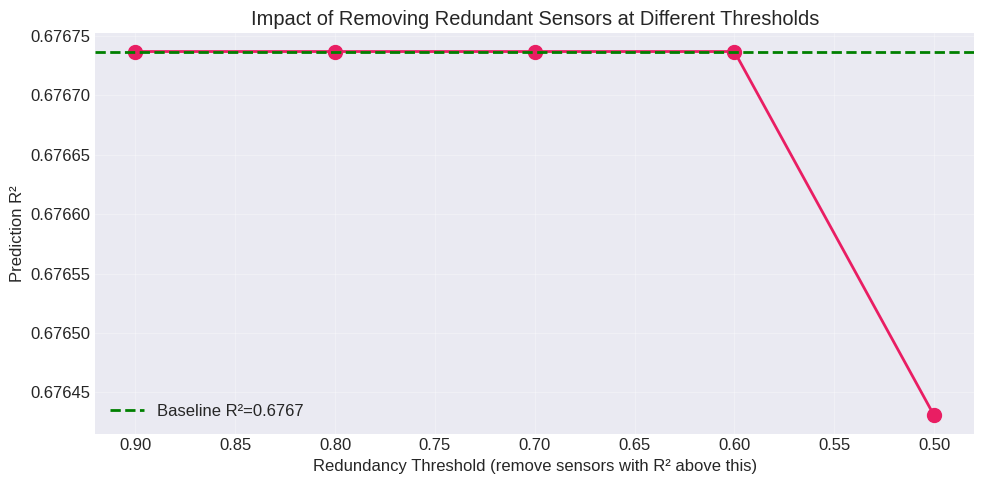

In [13]:
# Testing different redundancy thresholds
thresholds = [0.9, 0.8, 0.7, 0.6, 0.5]
threshold_results = []

for thresh in thresholds:
    removable = [s[0] for s in sorted_redundancy if s[1]['r2'] > thresh]
    remaining = [c for c in feature_cols if c not in removable]

    if len(remaining) == 0:
        continue

    col_idx = [feature_cols.index(c) for c in remaining]
    X_tr = X_train_s[:, col_idx]
    X_te = X_test_s[:, col_idx]

    lr_temp = LinearRegression()
    lr_temp.fit(X_tr, y_train_reg)
    y_pred = lr_temp.predict(X_te)

    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    threshold_results.append({
        'threshold': thresh,
        'sensors_removed': len(removable),
        'sensors_remaining': len(remaining),
        'removed_names': removable,
        'r2': r2,
        'rmse': rmse
    })

# Display
print('═══ Redundancy Threshold Exploration ═══')
print(f'  Baseline (all features): R²={r2_lr_full:.4f}, RMSE={rmse_lr_full:.4f}')
print(f'\n  {"Threshold":>10s} | {"Removed":>7s} | {"Remaining":>9s} | {"R²":>8s} | {"RMSE":>8s} | {"R² Δ":>8s}')
print('  ' + '-' * 65)
for r in threshold_results:
    delta = r['r2'] - r2_lr_full
    print(f'  {r["threshold"]:>10.1f} | {r["sensors_removed"]:>7d} | {r["sensors_remaining"]:>9d} | {r["r2"]:8.4f} | {r["rmse"]:8.4f} | {delta:+8.4f}')
    if r['sensors_removed'] > 0:
        print(f'           Removed: {r["removed_names"]}')

# Visualisation of the impact of removing redundant sensors on the accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ts = [r['threshold'] for r in threshold_results]
r2s = [r['r2'] for r in threshold_results]
ax.plot(ts, r2s, 'o-', color='#E91E63', lw=2, ms=10)
ax.axhline(r2_lr_full, color='green', ls='--', lw=2, label=f'Baseline R²={r2_lr_full:.4f}')
ax.set_xlabel('Redundancy Threshold (remove sensors with R² above this)')
ax.set_ylabel('Prediction R²')
ax.set_title('Impact of Removing Redundant Sensors at Different Thresholds')
ax.legend(); ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.tight_layout(); plt.show()

### Key Finding: Sensor Redundancy

The threshold sweep reveals a robust pattern: **removing the 8 most linearly predictable sensors (R² > 0.5) — E1, E2, pt1, pt2, eta1, eta2, pz1, pz2 — causes only a 0.0003 drop in R²** (from 0.6767 to 0.6764).

This confirms high information overlap among the raw kinematic variables. The energy (E) and transverse momentum (pt) of each electron are strongly correlated because pt is derived from the same momentum 4-vector — making them partially predictable from the other sensor readings.

Sensors that are truly irreplaceable (R² < 0.5) are the **azimuthal components** (phi1, phi2) and **transverse momentum components** (px1, py1, px2, py2) — these encode directional information that cannot be recovered from the energy/pseudorapidity measurements alone.

**Practical implication**: A minimal sensor set of ~17 sensors preserves virtually all predictive information, suggesting significant cost savings without accuracy loss.

## Impact of Removing Redundant Sensors

We test whether removing highly redundant sensors significantly impacts invariant mass prediction.

In [14]:
# ── Test removing redundant sensors ──────────────────────────────────────
if high_redundancy:
    # Remove all high-redundancy sensors
    reduced_cols = [c for c in feature_cols if c not in high_redundancy]
    col_idx = [feature_cols.index(c) for c in reduced_cols]

    X_tr_red = X_train_s[:, col_idx]
    X_te_red = X_test_s[:, col_idx]

    # Linear Regression
    lr_red = LinearRegression()
    lr_red.fit(X_tr_red, y_train_reg)
    y_pred_red = lr_red.predict(X_te_red)

    r2_red = r2_score(y_test_reg, y_pred_red)
    rmse_red = np.sqrt(mean_squared_error(y_test_reg, y_pred_red))

    print(f'═══ Impact of Removing Redundant Sensors ═══')
    print(f'  Removed sensors: {high_redundancy}')
    print(f'  Remaining features: {len(reduced_cols)}/{len(feature_cols)}')
    print(f'\n  Linear Regression — All features:    R²={r2_lr_full:.4f}, RMSE={rmse_lr_full:.4f}')
    print(f'  Linear Regression — Without redundant: R²={r2_red:.4f}, RMSE={rmse_red:.4f}')
    print(f'\n  R² change: {r2_red - r2_lr_full:+.4f}')
    print(f'  RMSE change: {rmse_red - rmse_lr_full:+.4f} GeV')

    if abs(r2_red - r2_lr_full) < 0.01:
        print(f'\n  Negligible impact — these sensors can be safely removed!')
    else:
        print(f'\n  Noticeable impact — removing these sensors degrades performance.')
else:
    print('No highly redundant sensors found.')

No highly redundant sensors found.
